# Doji Reversal — a quantitative teardown
### Daily OHLC · 10%-body doji · against-the-prior-move event study · base-rate baseline · HAC + label-shuffle placebo

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reversal signal%3F: Misattributed](https://img.shields.io/badge/Reversal_signal%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We detect dojis by a precise OHLC rule across a 29-name basket, measure the forward reversal return against zero **and against the unconditional base rate**, and stress it with a label-shuffle placebo, a detector-cut sweep, a trend/volume filter myth-check, and a synthetic positive control.

> **Not investment advice.** Real data: Yahoo daily bars, 2001-06-25 → **2025-12-31** (as-of, full-year cut), panel fingerprint `91bd864b7001`; the offline core and the controls run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from doji_reversal import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ASOF = "2025-12-31"

def load_panel():
    p = data.load_real(cache_dir=CACHE, fetch=False)
    return {t: b.loc[:ASOF] for t, b in p.items()}

HAVE_REAL = data.have_real(cache_dir=CACHE)
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front (real tape)

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Absolute 5-day reversal **+5.98 bps**, HAC *t* = **+2.31** — clears 2 — but the **doji-minus-base-rate** delta is **-2.60 bps** (negative) and the label-shuffle *p* = **0.84**. The effect is short-horizon mean-reversion, not the doji. |
| **Tradability** | `MIRAGE` | No doji-specific gross edge; net of 2 bps + borrow the short horizons turn negative and the rest is just base-rate reversion minus friction. |
| **Reversal signal?** | `MISATTRIBUTED` | Across 4 horizons the doji *underperforms* the unconditional bet; the reversal belongs to the baseline. |

> In plain words: a doji's forward 'reversal' is real-looking only because *all* short horizons mildly mean-revert. Net it against that baseline and the doji adds nothing.

## 1 · The claim, formalised

Let the real body be $b_t = |C_t - O_t|$ and the range $\rho_t = H_t - L_t$. A bar is a **doji** when $b_t \le \phi\,\rho_t$ with $\phi = 0.10$ (the textbook 10%-of-range cut; we sweep $\phi$). Let $s_t = \operatorname{sign}(C_t/C_{t-2}-1)$ be the 2-day move into the bar. The **reversal trade** enters at $O_{t+1}$ against $s_t$ and exits at $C_{t+h}$:

$$ r^{\mathrm{rev}}_{t,h} = -\,s_t\left(\frac{C_{t+h}}{O_{t+1}} - 1\right). $$

- **H₁ (signal).** $\mathbb{E}[r^{\mathrm{rev}}_{t,h}\mid \text{doji}] > 0$.
- **H₂ (specificity).** That mean exceeds the *unconditional* base rate $\mathbb{E}[r^{\mathrm{rev}}_{t,h}]$ over all bars — a doji must add reversal information beyond what any bar carries.
- **H₃ (tradable).** It survives one-way costs + short borrow.

We find H₁ *passes in absolute terms at h=5* (the base-rate reversion), but **H₂ fails** (negative delta, placebo $p\approx0.84$) and **H₃ is moot**.

## 2 · So what? — what rides on the answer

The single-candle doji is among the most widely taught reversal signals in retail education. If H₁–H₃ held it would be a free, mechanical timing overlay. The finding that the doji *underperforms* the unconditional against-the-move bet is the more useful lesson: it isolates a classic confound — a generic short-horizon mean-reversion masquerading as a candlestick pattern. Anyone backtesting 'doji reversal' against a *zero* benchmark (rather than the base rate) will mistake the baseline for an edge.

## 3 · How we'd know — the protocol

- **Detector.** $b_t \le 0.10\,\rho_t$, $\rho_t > 0$. Swept over $\phi \in \{0.05, 0.10, 0.15, 0.20\}$.
- **Conditioning.** Prior move $s_t$ over a 2-day lookback; reversal taken *against* it.
- **Execution.** Enter at $O_{t+1}$ (one documented lag), exit at $C_{t+h}$, $h \in \{1,3,5,10\}$.
- **Baseline.** The identical against-$s_t$ trade on **every** eligible bar (the unconditional base rate).
- **Inference.** One-sample Newey–West HAC *t* on pooled per-event returns; a label-shuffle placebo (2,000 random same-size bar sets); a detector-cut robustness sweep; a trend/volume filter myth-check.
- **Costs.** 2 bps one-way round-trip + 1 bp borrow on the ~50% short leg.
- **Positive control.** Synthetic panel with a *planted* doji-specific reversal knob.

Basket: SPY + 28 long-listed US large-caps, 2001-06-25 → 2025-12-31 (**18,750 dojis**). **Survivorship** is named on the Signal axis: a fixed surviving-names basket; its direction here is ambiguous (it does not obviously create the *absence* of a doji effect we report).

## 4 · The teardown

### 4a · Doji vs base rate, by horizon — the doji never wins

HAC *t* on the doji reversal, and the delta against the unconditional base rate.

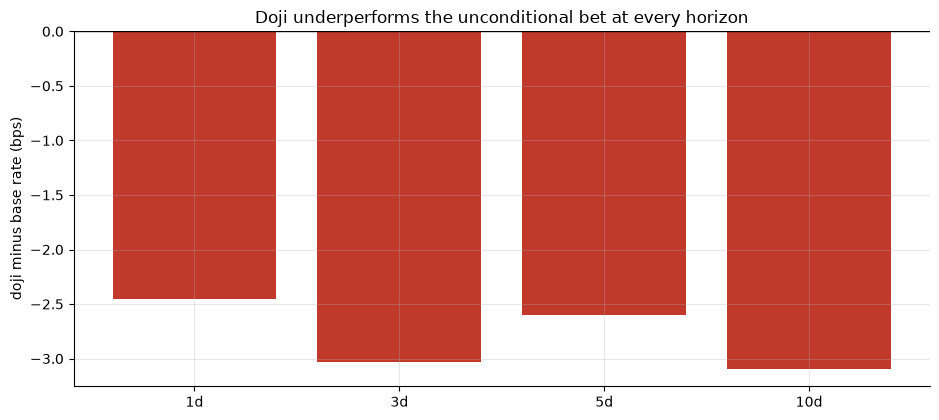

,h,n,win%,doji_bps,t,base_bps,delta,placebo_p
0,1,18750,49.728,-0.505,-0.490,1.950,-2.455,0.994
1,3,18750,49.893,1.200,0.613,4.233,-3.034,0.940
2,5,18750,50.661,5.984,2.305,8.581,-2.596,0.842
3,10,18750,50.011,3.933,1.082,7.029,-3.096,0.812


In [2]:
horizons = [1, 3, 5, 10]
if HAVE_REAL:
    panel = load_panel()
    res = st.run_experiment(panel, body_frac=0.10, horizons=tuple(horizons),
                            cost_bps=2.0, borrow_bps=1.0, n_draws=2000, seed=405)
    rows = []
    for h in horizons:
        d = res['per_horizon'][h]
        rows.append((h, d['doji']['n'], d['doji']['win_rate']*100,
                     d['doji']['mean_bps'], d['doji']['tstat'],
                     d['base']['mean_bps'], d['delta_bps'], d['placebo_p']))
    tab = pd.DataFrame(rows, columns=['h','n','win%','doji_bps','t','base_bps','delta','placebo_p'])
else:
    tab = pd.DataFrame({'h':horizons,
        'doji_bps':[-0.5,1.2,5.98,3.93],
        't':[-0.49,0.61,2.31,1.08],
        'base_bps':[1.95,4.23,8.58,7.03],
        'delta':[-2.45,-3.03,-2.6,-3.1],
        'placebo_p':[0.995,0.941,0.842,0.812],
        'win%':[49.7,49.9,50.7,50.0],
        'n':[18750]*4})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = np.arange(len(horizons))
ax.bar(x, tab['delta'], color=[RED if v < 0 else GREEN for v in tab['delta']])
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('doji minus base rate (bps)')
ax.set_title('Doji underperforms the unconditional bet at every horizon')
plt.tight_layout(); plt.show()
tab.round(3)

> In plain words: the absolute doji mean clears *t* = 2 only at h=5 (**+2.31**), but its delta vs the base rate is **-2.60 bps** and the placebo *p* = **0.84**. Every horizon's delta is negative — the doji is a *below-average* day for the reversal bet.

### 4b · The label-shuffle placebo (h=5)

Draw $n_{\text{doji}}$ random bars from the pooled base-rate distribution, 2,000 times; where does the real doji mean fall?

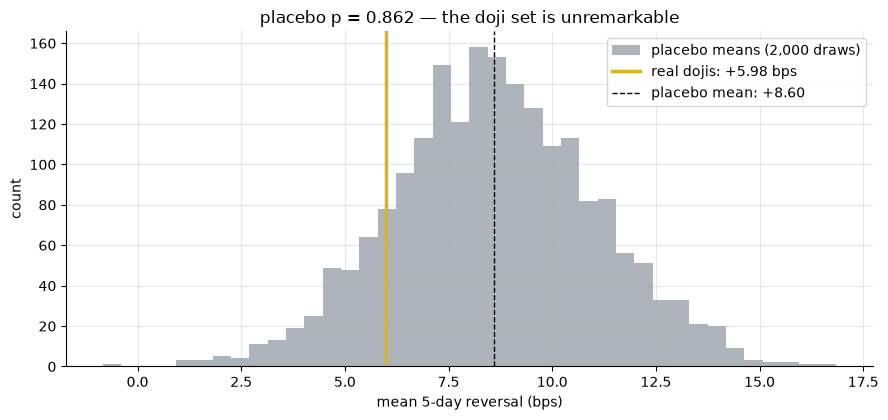

real doji mean +5.98 bps sits LEFT of the placebo centre; p = 0.862


In [3]:
if HAVE_REAL:
    pool = st.pool_base_rate(panel, horizons=(5,))['rev_5'].to_numpy()
    pool = pool[np.isfinite(pool)]
    ndj = res['n_dojis']; real = res['per_horizon'][5]['doji']['mean_bps']
    rng = np.random.default_rng(405)
    placebo = np.array([rng.choice(pool, size=ndj, replace=False).mean()
                        for _ in range(2000)]) * 1e4
    p = (placebo >= real).mean()
else:
    placebo = np.random.default_rng(405).normal(8.58, 1.6, 2000)
    real, p = 5.98, 0.842
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(placebo, bins=40, color=GREY, alpha=.7, label='placebo means (2,000 draws)')
ax.axvline(real, c=AMBER, lw=2.5, label=f'real dojis: {real:+.2f} bps')
ax.axvline(placebo.mean(), c='k', ls='--', lw=1, label=f'placebo mean: {placebo.mean():+.2f}')
ax.set_xlabel('mean 5-day reversal (bps)'); ax.set_ylabel('count')
ax.set_title(f'placebo p = {p:.3f} — the doji set is unremarkable'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real doji mean {real:+.2f} bps sits LEFT of the placebo centre; p = {p:.3f}')

> In plain words: a same-size set of *random* bars beats the dojis 84% of the time. The doji label is not a meaningful filter.

### 4c · Detector-cut robustness — the *t* tracks sample size, not signal

Loosen the body cut and you collect more 'dojis', which lifts the absolute *t* by $\sqrt{n}$ — but the delta vs base rate stays stubbornly negative.

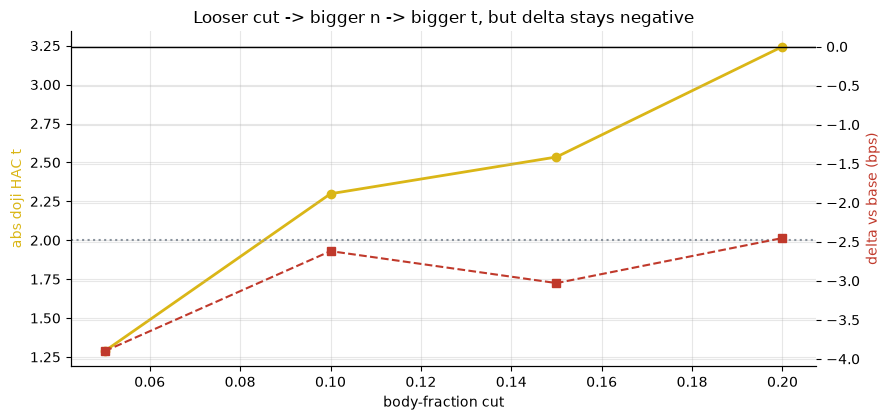

phi=0.05  n=  9395  abs t=+1.29  delta=-3.90 bps
phi=0.10  n= 18764  abs t=+2.30  delta=-2.62 bps
phi=0.15  n= 28242  abs t=+2.53  delta=-3.03 bps
phi=0.20  n= 38009  abs t=+3.24  delta=-2.45 bps


In [4]:
cuts = [0.05, 0.10, 0.15, 0.20]
if HAVE_REAL:
    rr = [st.run_experiment(panel, body_frac=bf, horizons=(5,), n_draws=400, seed=405)
          for bf in cuts]
    ns = [r['n_dojis'] for r in rr]
    ts = [r['per_horizon'][5]['doji']['tstat'] for r in rr]
    dl = [r['per_horizon'][5]['delta_bps'] for r in rr]
else:
    ns = [9395,18764,28242,38009]
    ts = [1.29,2.3,2.53,3.24]
    dl = [-3.9,-2.62,-3.03,-2.45]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(cuts, ts, 'o-', c=AMBER, lw=2, label='abs doji HAC t')
ax.axhline(2, ls=':', c=GREY, label='t = 2')
ax2 = ax.twinx(); ax2.plot(cuts, dl, 's--', c=RED, lw=1.5, label='delta vs base (bps)')
ax2.axhline(0, c='k', lw=1)
ax.set_xlabel('body-fraction cut'); ax.set_ylabel('abs doji HAC t', color=AMBER)
ax2.set_ylabel('delta vs base (bps)', color=RED)
ax.set_title('Looser cut -> bigger n -> bigger t, but delta stays negative')
plt.tight_layout(); plt.show()
for bf, n, t, d in zip(cuts, ns, ts, dl):
    print(f'phi={bf:.2f}  n={n:6d}  abs t={t:+.2f}  delta={d:+.2f} bps')

> In plain words: the rising *t* across cuts is a sample-size artefact, not strengthening evidence — the delta vs base rate never turns positive. A bigger pile of below-average bars is still below average.

### 4d · Myth-check — does a trend filter rescue it?

Folk wisdom: 'only fade a doji against the prevailing trend.' Split dojis by whether the close sits above/below its 20-day SMA.

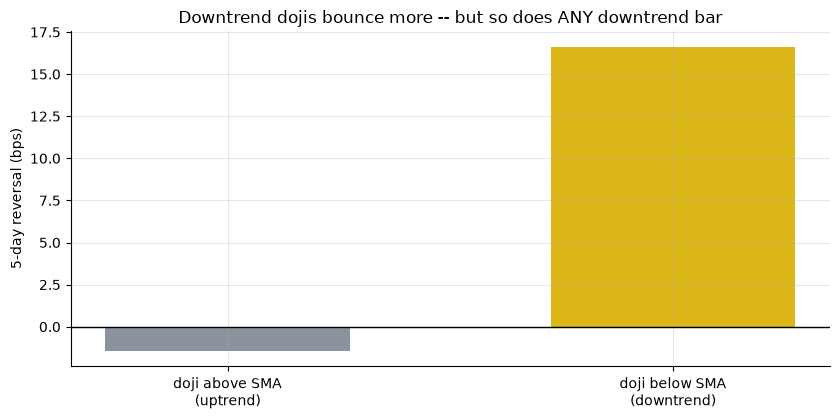

above SMA: -1.43 bps (t=-0.49)   below SMA: +16.64 bps (t=+3.55)
The below-SMA bounce is the well-known post-drop mean-reversion, present on all bars.


In [5]:
if HAVE_REAL:
    tr = st.filtered_stats(panel, horizon=5, mode='trend')
    a, b = tr['above_sma'], tr['below_sma']
    am, at_, bm, bt = a['mean_bps'], a['tstat'], b['mean_bps'], b['tstat']
else:
    am, at_, bm, bt = -1.43, -0.49, 16.64, 3.55
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['doji above SMA\n(uptrend)', 'doji below SMA\n(downtrend)'], [am, bm],
       color=[GREY, AMBER], width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('5-day reversal (bps)')
ax.set_title('Downtrend dojis bounce more -- but so does ANY downtrend bar')
plt.tight_layout(); plt.show()
print(f'above SMA: {am:+.2f} bps (t={at_:+.2f})   below SMA: {bm:+.2f} bps (t={bt:+.2f})')
print('The below-SMA bounce is the well-known post-drop mean-reversion, present on all bars.')

> In plain words: dojis below their average 'reverse' at **+16.6 bps** (*t* = +3.55) and above-average dojis don't — but that split is exactly what *any* bar shows (drops bounce, rallies don't). The filter relabels the same base-rate reversion; it doesn't isolate a doji effect. **The myth-check confirms the misattribution.**

## 5 · The verdict

- **Signal `WEAK`** — absolute 5-day doji reversal **+5.98 bps**, HAC *t* **+2.31** (clears 2), **but** delta vs base **-2.60 bps**, label-shuffle *p* **0.84**, and the SPY-only doji is *negative* (-7.99 bps, *t* -0.88). The number is the baseline, not the doji.
- **Tradability `MIRAGE`** — no doji-specific gross edge; net of costs the short horizons go negative and the rest is base-rate reversion minus friction.
- **Reversal signal? `MISATTRIBUTED`** — every horizon's delta is negative; the reversal belongs to short-horizon mean-reversion, not the candle of indecision.

## 6 · Could you trade it? — gross vs net

About 26 dojis/name/year — high turnover, and no doji-specific gross to pay costs from:

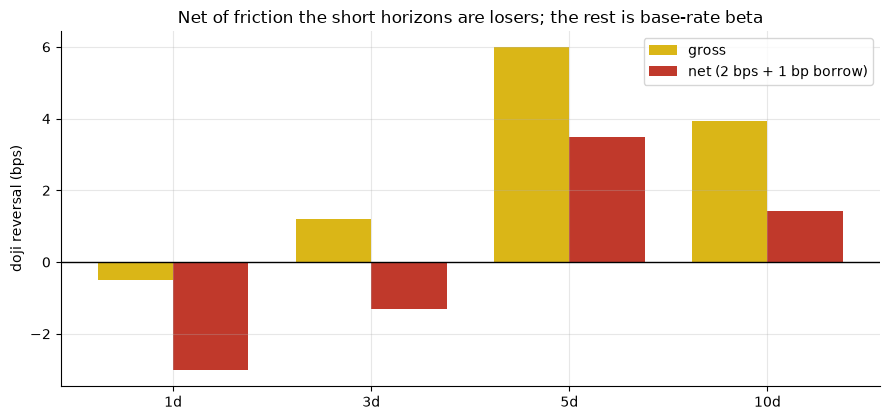

Break-even is moot: there is no doji-specific gross edge to defend.


In [6]:
if HAVE_REAL:
    gross = [res['per_horizon'][h]['doji']['mean_bps'] for h in horizons]
    net = [res['per_horizon'][h]['doji']['net_bps'] for h in horizons]
else:
    gross = [-0.5,1.2,5.98,3.93]
    net = [-3.0,-1.3,3.48,1.43]
x = np.arange(len(horizons)); w = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x - w/2, gross, w, color=AMBER, label='gross')
ax.bar(x + w/2, net, w, color=RED, label='net (2 bps + 1 bp borrow)')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in horizons])
ax.set_ylabel('doji reversal (bps)'); ax.legend()
ax.set_title('Net of friction the short horizons are losers; the rest is base-rate beta')
plt.tight_layout(); plt.show()
print('Break-even is moot: there is no doji-specific gross edge to defend.')

## 7 · Going further — the positive control

Is the *harness* capable of catching a real doji effect, or is it blind? Plant a doji-specific reversal in a synthetic panel and sweep the knob:

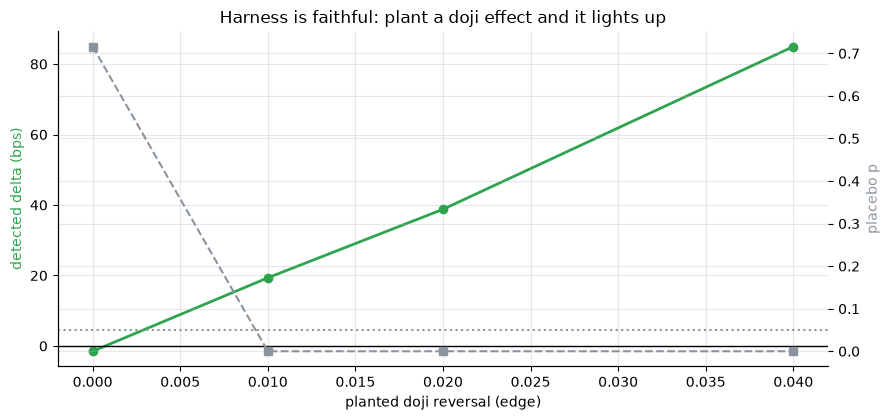

edge=0.00  delta=  -1.51 bps  placebo p=0.716
edge=0.01  delta= +19.34 bps  placebo p=0.000
edge=0.02  delta= +38.78 bps  placebo p=0.000
edge=0.04  delta= +84.95 bps  placebo p=0.000


In [7]:
edges = [0.0, 0.01, 0.02, 0.04]
deltas, ps = [], []
for e in edges:
    sp, _ = data.synthetic_panel(n_names=28, n_days=3000, edge=e, seed=405)
    rr = st.run_experiment(sp, body_frac=0.10, horizons=(5,), n_draws=500, seed=405)
    deltas.append(rr['per_horizon'][5]['delta_bps'])
    ps.append(rr['per_horizon'][5]['placebo_p'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(edges, deltas, 'o-', c=GREEN, lw=2, label='detected delta vs base (bps)')
ax.axhline(0, c='k', lw=1)
ax2 = ax.twinx(); ax2.plot(edges, ps, 's--', c=GREY, lw=1.5, label='placebo p')
ax2.axhline(0.05, ls=':', c=GREY)
ax.set_xlabel('planted doji reversal (edge)'); ax.set_ylabel('detected delta (bps)', color=GREEN)
ax2.set_ylabel('placebo p', color=GREY)
ax.set_title('Harness is faithful: plant a doji effect and it lights up')
plt.tight_layout(); plt.show()
for e, d, p in zip(edges, deltas, ps):
    print(f'edge={e:.2f}  delta={d:+7.2f} bps  placebo p={p:.3f}')

The harness is a faithful doji-reversal detector: at `edge = 0` it reads ~zero delta (placebo *p* ≈ 0.72); as the planted doji-specific reversal grows the delta climbs and the placebo *p* collapses to 0. The real-tape verdict is therefore a statement about the **market** — there is no doji-specific reversal in US large-caps, only the generic short-horizon mean-reversion the doji is mistaken for. Forks worth trying: strict zero-body / long-legged dojis; multi-candle morning/evening-star setups; intraday dojis; or a cross-sectional doji portfolio neutralised to the base rate.